## Instabilité d'un jet de Bickley dans le modèle QG barotrope
Equations : 
$$
\begin{align}
&q = \left(\frac{\partial^2}{\partial x^2} + \frac{\partial^2}{\partial y^2}\right) \psi +\beta y \\
&\frac{\partial q}{\partial t} + \mathrm{J}\left( \psi, q\right) = 0
\end{align}
$$

Ici, $x\in [0, 2\pi]$ et $y\in[-1, 1]$. Le champ de vitesse initial est de la forme :
$$
U(x, y) = U_0 \mathrm{sech}^2{\frac{y}{\alpha}} = U_0\frac{1}{\cosh^2{\frac{y}{\alpha}} }
$$
Ici, on prends $\alpha = 0.2$ et $U_0 = 2.0$. Les CLs sur $\psi$ sont :
$$
\begin{align}
&\text{Periodiques selon x}\\
&\psi(x, -1, t) = \psi(x, 1, t) = T_0
\end{align}
$$

Où $T_0$ est le transport moyen, que l'on est obligé de prendre non nul, sinon il ne se passe rien. D'après le critère de Rayleigh, le jet est instable si le gradient de PV change de signe sur le domaine : 
$$
\beta - \frac{\mathrm{d}^2 U}{\mathrm{d}y^2} = 0
$$

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

#print(ROOT)
#print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [74]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.colors as mcolors


import chebyshev

max U_cheb 0.9961854446766282


Text(0, 0.5, 'y')

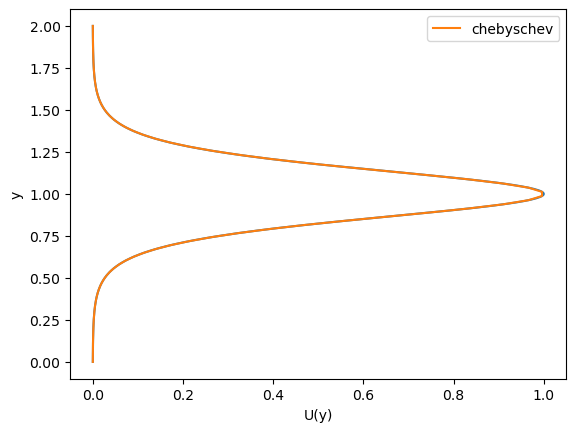

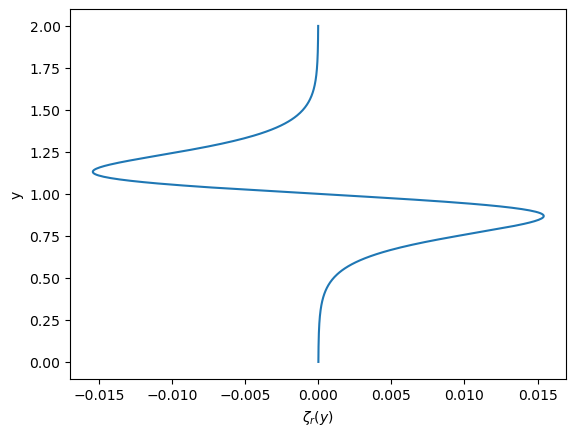

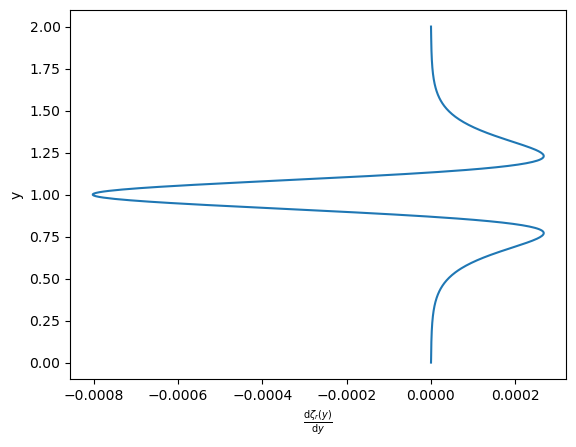

In [77]:
N_points = 500
x_lin = np.linspace(0.0, 2.0*np.pi,N_points, endpoint = False)
y_lin = np.linspace(0.0, 2.0, N_points)

def BickleyJet(y, gamma, U0=1.0, center = 0.0):
    "Jet de Bickley, de largeur gamma et de valeur max U0 (en y=0), centré en center"
    return U0*(np.cosh((y - center)/gamma))**(-2.0)

U = BickleyJet(y_lin, 0.2, center = 1.0)

y_cheb = chebyshev.collocation_points(128, a = 0.0, b = 2.0)
U_cheb  = BickleyJet(y_cheb, 0.2, center = 1.0)


print(f"max U_cheb {U_cheb.max()}")
vort = np.gradient(U)
grad_vort = np.gradient(vort)

fig = plt.figure()
plt.plot(U, y_lin)
plt.plot(U_cheb, y_cheb, label = 'chebyschev')
plt.xlabel('U(y)')
plt.ylabel('y')
plt.legend()

fig = plt.figure()
plt.plot(vort, y_lin)
plt.xlabel(f"$\zeta_r(y)$")
plt.ylabel('y')

fig = plt.figure()
plt.plot(grad_vort, y_lin)
plt.xlabel(r"$\frac{\mathrm{d}\zeta_r(y)}{\mathrm{d}y}$")
plt.ylabel('y')

## Test code ``Bickley_BT_Test.py``

In [4]:
import xarray as xr
import os
import IPython.display as ipd
repertoire_courant = os.getcwd()
print(repertoire_courant)

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\Test_Bickley_BT


In [102]:
#Permets de charger le contenu du fichier en mémoire.

#exp_name = 'test_bickley_w_transport_dealias_LF'
exp_name = "test_bickley_visc2"
Ds_his = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+'_his.nc')

Ds_diags = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+"_diags.nc")

ipd.display(Ds_his)
ipd.display(Ds_diags)

<xarray.Dataset> Size: 118MB
Dimensions:    (t: 301, x: 128, y: 128)
Coordinates:
  * t          (t) float64 2kB 0.0 0.05006 0.1001 0.1502 ... 14.9 14.95 15.0
  * x          (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y          (y) float64 1kB 1.0 0.9997 0.9988 0.9972 ... -0.9988 -0.9997 -1.0
Data variables:
    psi        (t, x, y) float64 39MB 1.0 0.9998 0.9991 ... 0.000226 0.0
    vorticity  (t, x, y) float64 39MB 0.6818 -0.01672 ... -0.009594 0.2648
    PV         (t, x, y) float64 39MB -0.04362 -0.01672 ... -0.009594 -0.04375
Attributes: (12/30)
    title:          test_bickley_visc2_his.nc
    Nx:             128
    Ny:             128
    x_bounds:       [0.         6.28318531]
    y_bounds:       [-1.  1.]
    list_geometry:  ['basin', 'biperiodic', 'zonal_channel']
    ...             ...
    exp_p:          5.0
    Model:          BarotropicQG
    beta:           0.0
    inv_Rd2:        0.0
    T_0:            1.0
    visc2:          4e-09

<xarray.Dataset> Size: 14kB
Dimensions:           (t: 301)
Coordinates:
  * t                 (t) float64 2kB 0.0 0.05006 0.1001 ... 14.9 14.95 15.0
Data variables:
    kinetic_energy    (t) float64 2kB 2.156 2.156 2.156 ... 2.155 2.155 2.155
    potential_energy  (t) float64 2kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    total_energy      (t) float64 2kB 2.156 2.156 2.156 ... 2.155 2.155 2.155
    PV_total          (t) float64 2kB 0.001777 0.001777 ... 0.001488 0.001482
    enstrophy         (t) float64 2kB 16.75 16.75 16.75 ... 14.95 14.96 14.97
Attributes: (12/30)
    title:          test_bickley_visc2_diags.nc
    Nx:             128
    Ny:             128
    x_bounds:       [0.         6.28318531]
    y_bounds:       [-1.  1.]
    list_geometry:  ['basin', 'biperiodic', 'zonal_channel']
    ...             ...
    exp_p:          5.0
    Model:          BarotropicQG
    beta:           0.0
    inv_Rd2:        0.0
    T_0:            1.0
    visc2:          4e-09

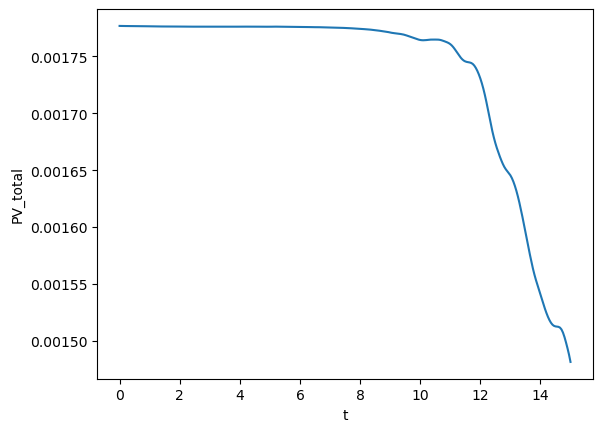

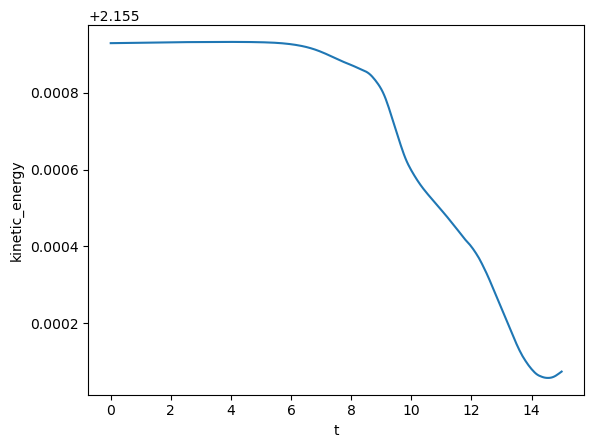

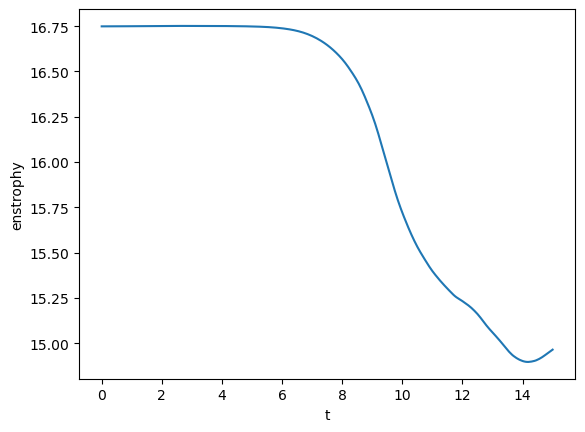

In [103]:
fig = plt.figure()
Ds_diags['PV_total'].plot()
plt.savefig(repertoire_courant + rf"//{exp_name}//"+'PV_total_exp_1.png')


fig = plt.figure()
Ds_diags['kinetic_energy'].plot()
#plt.xlim(left = 5.0, right = 6.3)
plt.savefig(repertoire_courant + rf"//{exp_name}//"+'KE_total_exp_1.png')

fig = plt.figure()
Ds_diags['enstrophy'].plot()
plt.savefig(repertoire_courant + rf"//{exp_name}//"+'Enstr_total_exp_1.png')

<Figure size 640x480 with 0 Axes>

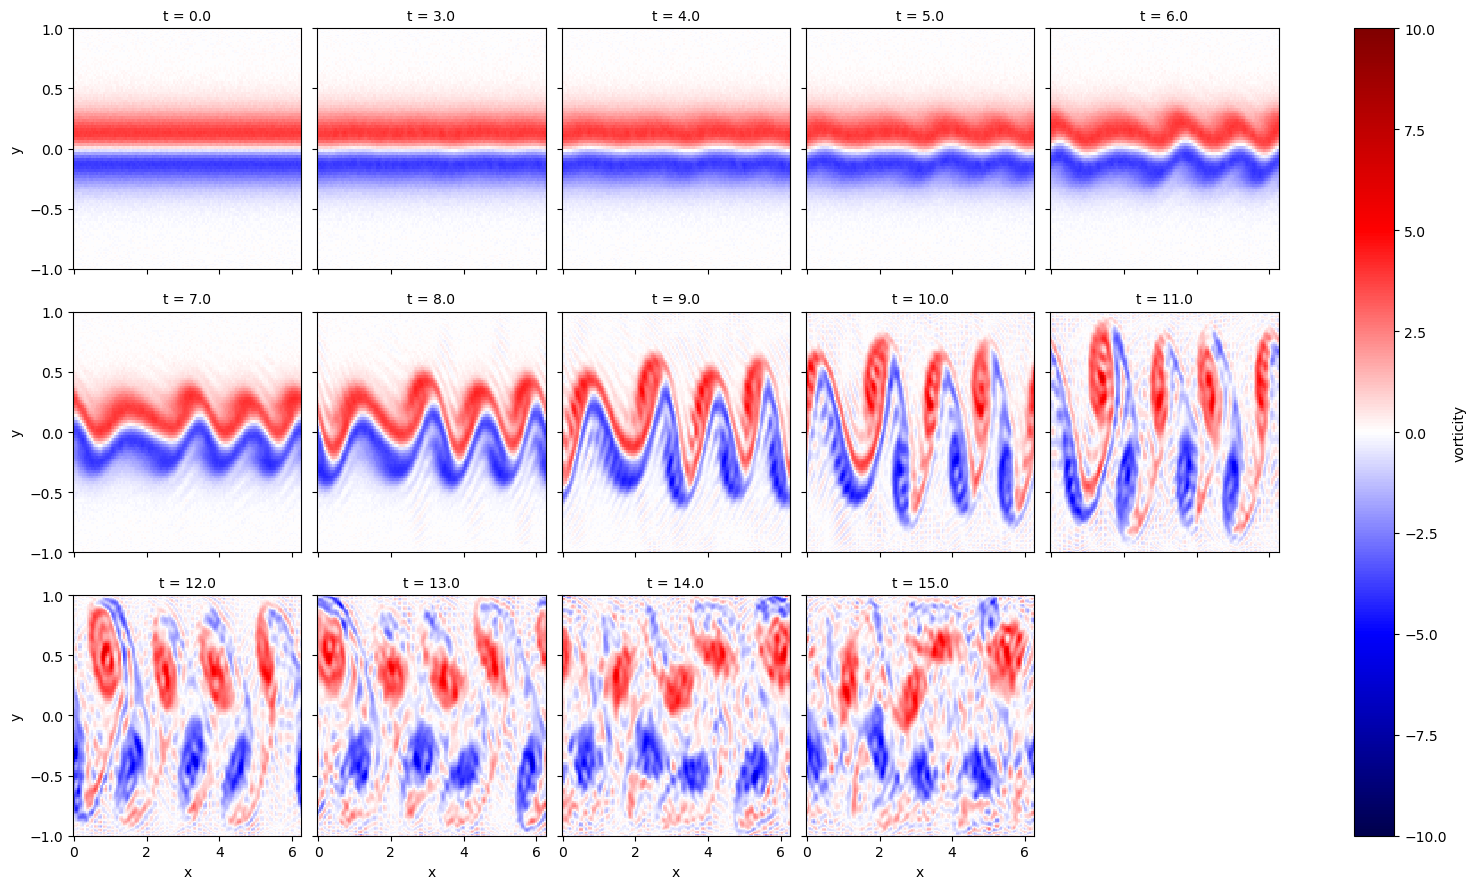

In [104]:
liste_t = [0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0,
           10.0, 11.0, 12.0, 13.0, 14.0, 15.0]

fig = plt.figure()
Ds_his['vorticity'].sel(t=liste_t, method = 'nearest').plot.pcolormesh(col = 't',
                                                                       col_wrap = 5,
                                                                       vmin = -10.0,
                                                                       vmax = 10.0,
                                                                       x = 'x', y = 'y',
                                                                       cmap = 'seismic')
plt.savefig(repertoire_courant + rf"//{exp_name}//"+f'{exp_name}_vort_snap.png')

In [8]:
Ds_his.attrs

{'title': 'test_bickley_w_transport_dealias_LF_his.nc',
 'Nx': 128,
 'Ny': 128,
 'x_bounds': array([0.        , 6.28318531]),
 'y_bounds': array([-1.,  1.]),
 'list_geometry': ['basin', 'biperiodic', 'zonal_channel'],
 'geometry': 'zonal_channel',
 'time_scheme': 'LeapFrog',
 'max_time': 15.0,
 'max_it': 1000000,
 'max_speed': 25.0,
 'cfl': 1.0,
 'adaptable_dt': 'True',
 'dt': 0.1,
 'output_path': 'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\Test_Bickley_BT',
 'date': '2026:09:17-17:01:43',
 'exp_name': 'test_bickley_w_transport_dealias_LF',
 'exp_dir': 'C:\\Users\\evanl\\Documents\\Cours M2 POC\\Stage LOPS\\pyTQG\\Test_Bickley_BT',
 'freq_his': 0.05,
 'freq_diags': 0.05,
 'apply_dealias': 'True',
 'dealias_order': 'after_product',
 'Fourier_coeff': 0.6666666666666666,
 'exp_alpha': 100.0,
 'exp_p': 8.0,
 'Model': 'BarotropicQG',
 'beta': 0.0,
 'inv_Rd2': 0.0,
 'T_0': 1.0}

In [105]:
import importlib
import post_processing as ps
importlib.reload(ps)

PostProcess = ps.PostProcess(Ds_his.attrs)


In [59]:
ps.animate(Ds_his['psi'], regular_grid = False, fps = 10)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=100, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

In [60]:
u = -PostProcess.derivative(Ds_his['psi'], "y")
v = PostProcess.derivative(Ds_his['psi'], "x")

U = np.sqrt(u**2+v**2)

ps.animate(u, regular_grid = False, cmap = 'viridis')

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

In [106]:
ps.animate(Ds_his['vorticity'],
           x = 'x', y = 'y',
           regular_grid = False, clim = (-10.0, 10.0), 
           fps = 50)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=20, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

In [13]:
ps.animate(Ds_his['PV'], regular_grid = False, clim = (-10.0, 10.0))

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

In [66]:
u_max = 0.01
u = 0.7
dt_adv = PostProcess.Grid.dx_min/u
visc = 1.5 * u_max * PostProcess.Grid.dx_min
visc = 7.0e-7

dt_diff = PostProcess.Grid.dx_min**2/visc

print(f"u_max = {u_max}")
print(f"u = {u}")
print(f"visc = {visc}")
print(f"dx_min = {PostProcess.Grid.dx_min}")
print(f"dt_adv = {dt_adv}")
print(f"dt_diff = {dt_diff}")
print(f"dt_adv < dt_diff : {dt_adv < dt_diff}")

u_max = 0.01
u = 0.7
visc = 7e-07
dx_min = 0.0003059427469168652
dt_adv = 0.0004370610670240931
dt_diff = 0.13371566341576718
dt_adv < dt_diff : True


Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

<Figure size 640x480 with 0 Axes>

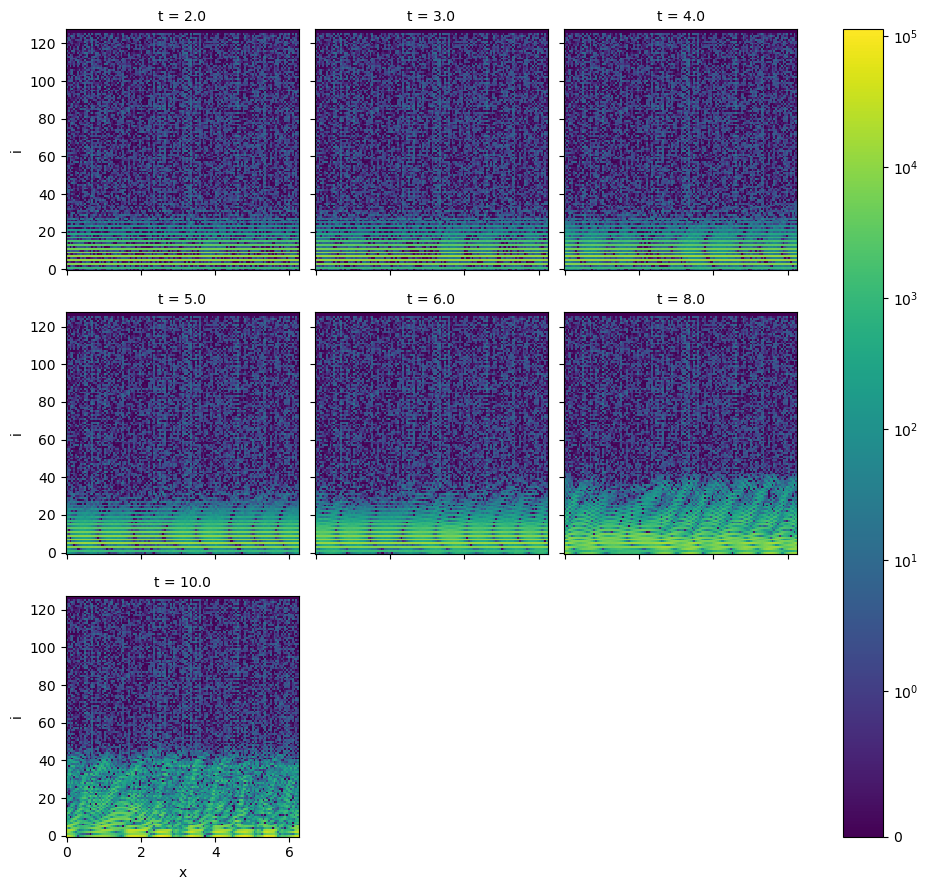

In [109]:
spec_vort_y = PostProcess.var_spectrum_2D(Ds_his['vorticity'], "y")
#ipd.display(spec_U)
symlog_norm = mcolors.SymLogNorm(linthresh=1, vmin=0, vmax=spec_vort_y.max(), base=10)

liste_t = [2.0, 3.0, 4.0, 5.0, 6.0, 8.0, 10.0]
fig = plt.figure()
spec_vort_y.sel(t = liste_t, method = 'nearest').plot.pcolormesh(x = 'x',
                                                                 y= 'i', 
                                                                 col = 't',
                                                                 col_wrap = 3,
                                                                 norm = symlog_norm)

plt.savefig(f"{exp_name}_spec_vort_y.png")

ps.animate(spec_vort_y, x = 'x', y = 'i', log_cnorm = True)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

<Figure size 640x480 with 0 Axes>

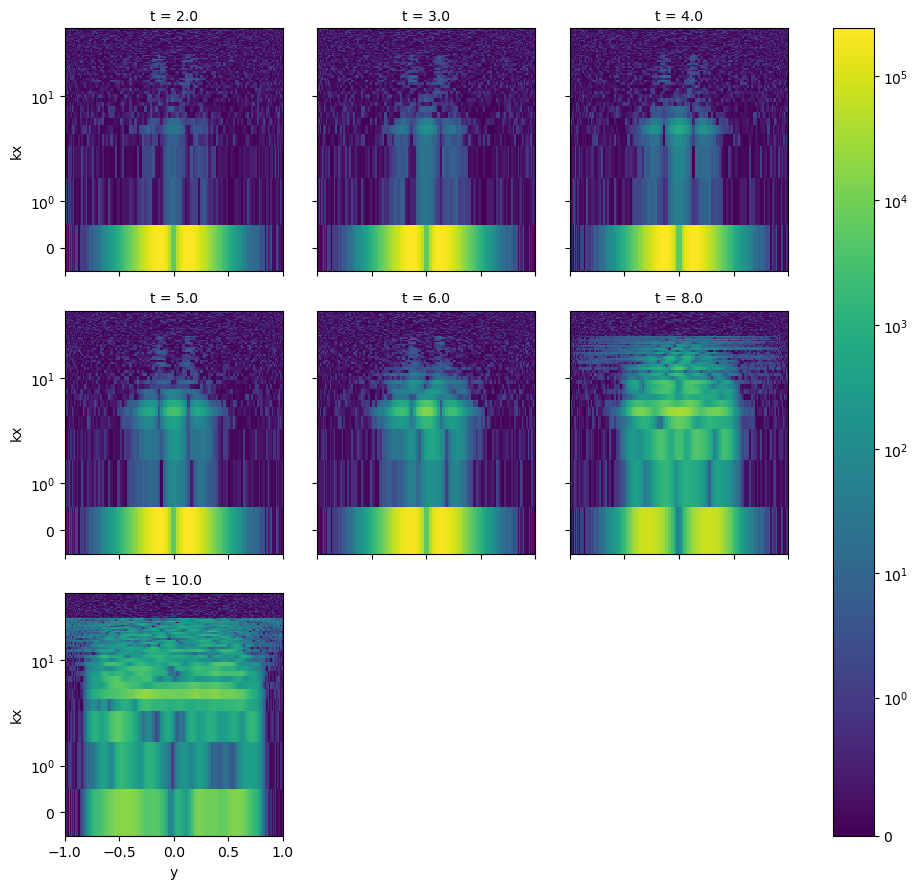

In [111]:
spec_vort_x = PostProcess.var_spectrum_2D(Ds_his['vorticity'], "x")
symlog_norm = mcolors.SymLogNorm(linthresh=1, vmin=0, vmax=spec_vort_x.max(), base=10)


fig = plt.figure()
spec_vort_x.sel(t = liste_t, method = 'nearest').plot.pcolormesh(x = 'y',
                                                                 y= 'kx', 
                                                                 yscale = 'symlog',
                                                                 col = 't',
                                                                 col_wrap = 3,
                                                                 norm = symlog_norm)
plt.savefig(f"{exp_name}_spec_vort_x.png")

ps.animate(spec_vort_x, x = 'y', y = 'kx', log_cnorm = True, logy = False, regular_grid = False)

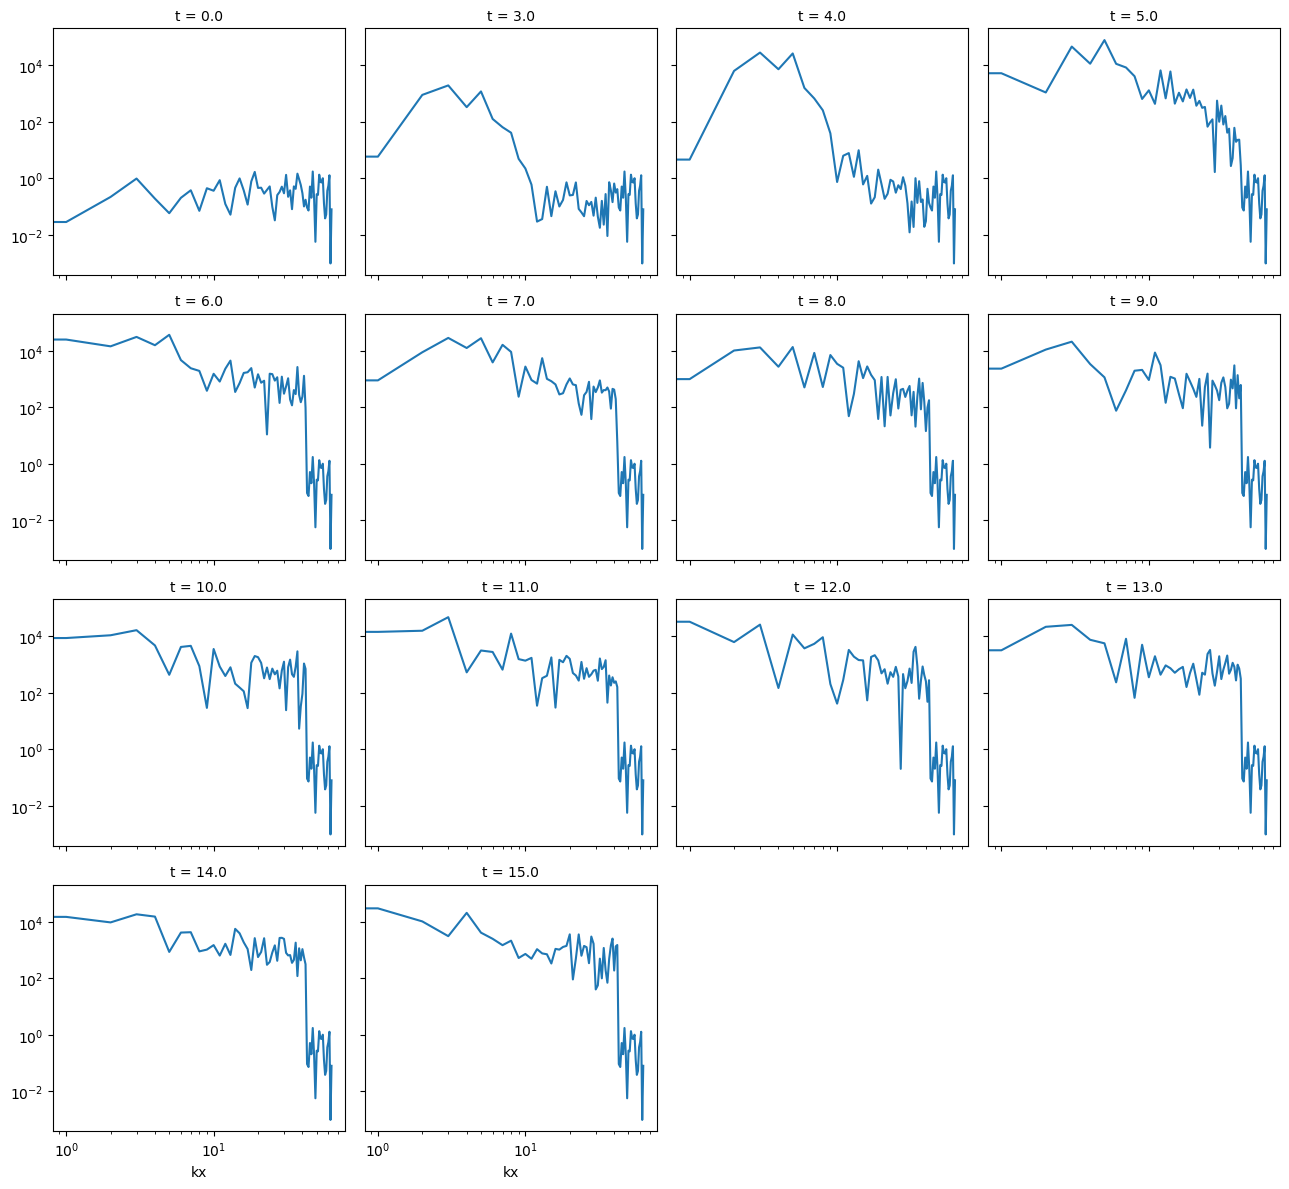

In [16]:
#Vue du spectre au centre du canal
spec_visc_center = spec_vort_x.sel(y = 0.0, method = 'nearest')
liste_t = [0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0,
           10.0, 11.0, 12.0, 13.0, 14.0, 15.0]

spec_visc_center.sel(t = liste_t, method = 'nearest').plot(row = 't', xscale = 'log', yscale = 'log', col_wrap = 4)

## Meme simulation sans déaliasing


In [17]:
exp_name = 'test_bickley_w_transport'

Ds_his_w_dealias = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+'_his.nc')

Ds_diags_w_dealias = xr.load_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+"_diags.nc")

PostProcess_w_dealias = ps.PostProcess(Ds_his_w_dealias.attrs)

ipd.display(Ds_his_w_dealias)
ipd.display(Ds_diags_w_dealias)

<xarray.Dataset> Size: 50MB
Dimensions:    (t: 128, x: 128, y: 128)
Coordinates:
  * t          (t) float64 1kB 0.0 0.05027 0.1003 0.1503 ... 6.2 6.25 6.3 6.35
  * x          (x) float64 1kB 0.0 0.04909 0.09817 0.1473 ... 6.136 6.185 6.234
  * y          (y) float64 1kB 1.0 0.9997 0.9988 0.9972 ... -0.9988 -0.9997 -1.0
Data variables:
    psi        (t, x, y) float64 17MB 1.0 0.9997 0.9989 ... 0.0003332 0.0
    vorticity  (t, x, y) float64 17MB -0.8413 0.07863 0.0121 ... 0.1251 -0.09384
    PV         (t, x, y) float64 17MB 0.04552 0.07863 0.0121 ... 0.1251 -0.01609
Attributes: (12/29)
    title:                  test_bickley_w_transport_his.nc
    Nx:                     128
    Ny:                     128
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    1.0

<xarray.Dataset> Size: 6kB
Dimensions:           (t: 128)
Coordinates:
  * t                 (t) float64 1kB 0.0 0.05027 0.1003 ... 6.25 6.3 6.35
Data variables:
    kinetic_energy    (t) float64 1kB 3.917 3.917 3.917 ... 3.986 4.003 4.068
    potential_energy  (t) float64 1kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    total_energy      (t) float64 1kB 3.917 3.917 3.917 ... 3.986 4.003 4.068
    PV_total          (t) float64 1kB 0.01795 0.01795 ... 0.01518 0.006603
    enstrophy         (t) float64 1kB 67.06 67.06 67.06 ... 444.1 572.3 1.07e+03
Attributes: (12/29)
    title:                  test_bickley_w_transport_diags.nc
    Nx:                     128
    Ny:                     128
    x_bounds:               [0.         6.28318531]
    y_bounds:               [-1.  1.]
    list_geometry:          ['basin', 'biperiodic', 'zonal_channel']
    ...                     ...
    dealias_exp_alpha:      100.0
    dealias_exp_p:          8.0
    Model:                  BarotropicQG
    beta:                   0.0
    inv_Rd2:                0.0
    T_0:                    1.0

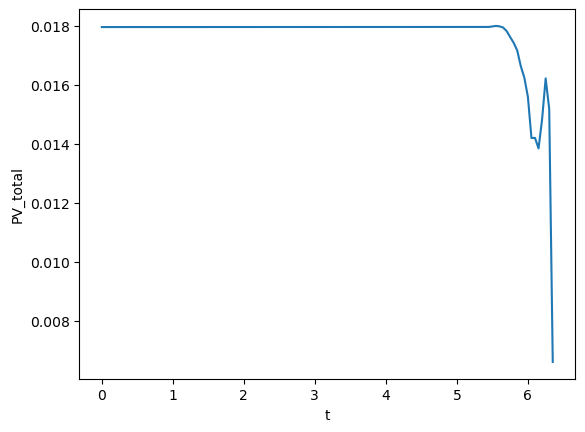

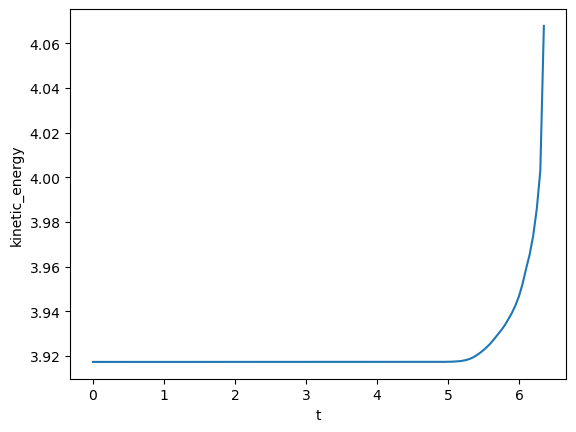

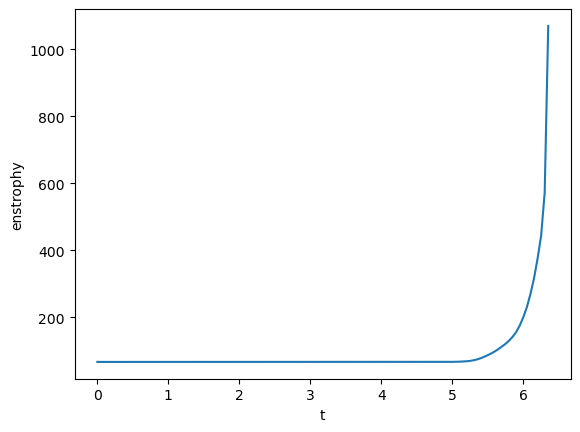

In [18]:
fig = plt.figure()
Ds_diags_w_dealias['PV_total'].plot()
fig = plt.figure()
Ds_diags_w_dealias['kinetic_energy'].plot()
fig = plt.figure()
Ds_diags_w_dealias['enstrophy'].plot()

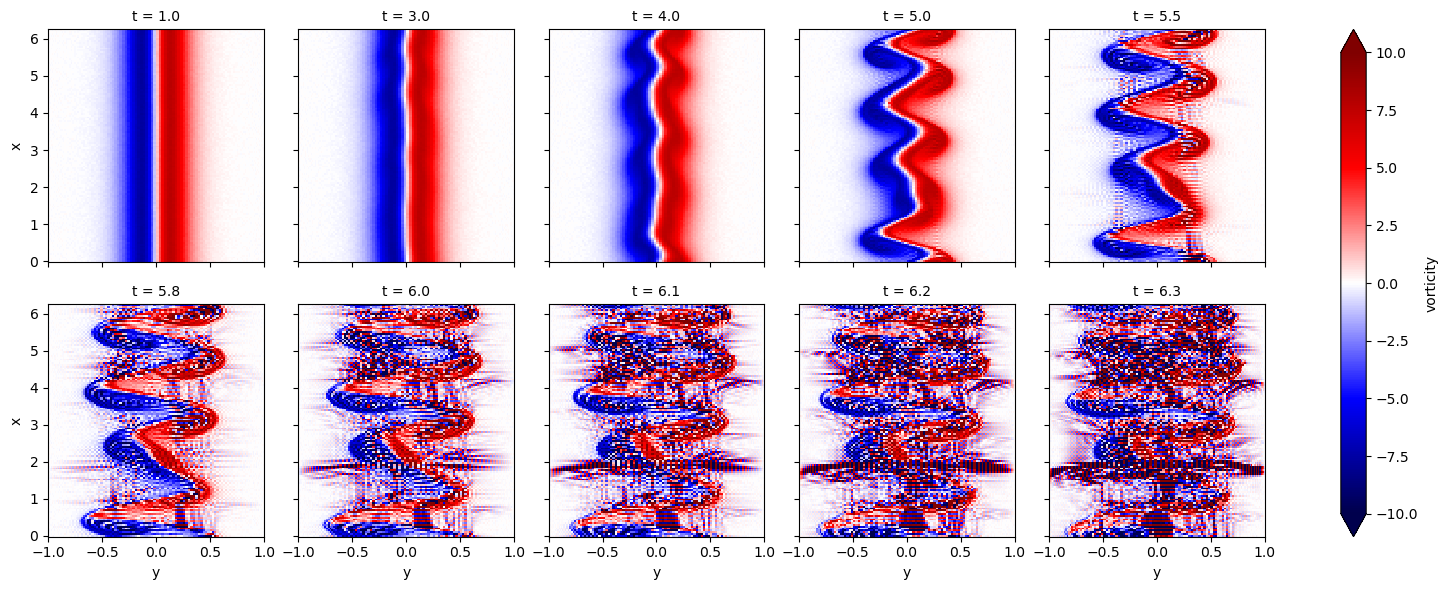

In [19]:
liste_t_w_dealias = [1.0, 3.0, 4.0, 5.0, 5.5, 5.8, 6.0, 6.1, 6.2, 6.3]
Ds_his_w_dealias['vorticity'].sel(t=liste_t_w_dealias, method = 'nearest').plot.pcolormesh(col = 't',
                                                                                           col_wrap = 5,
                                                                                           vmin = -10.0,
                                                                                           vmax = 10.0,
                                                                                           cmap = 'seismic')

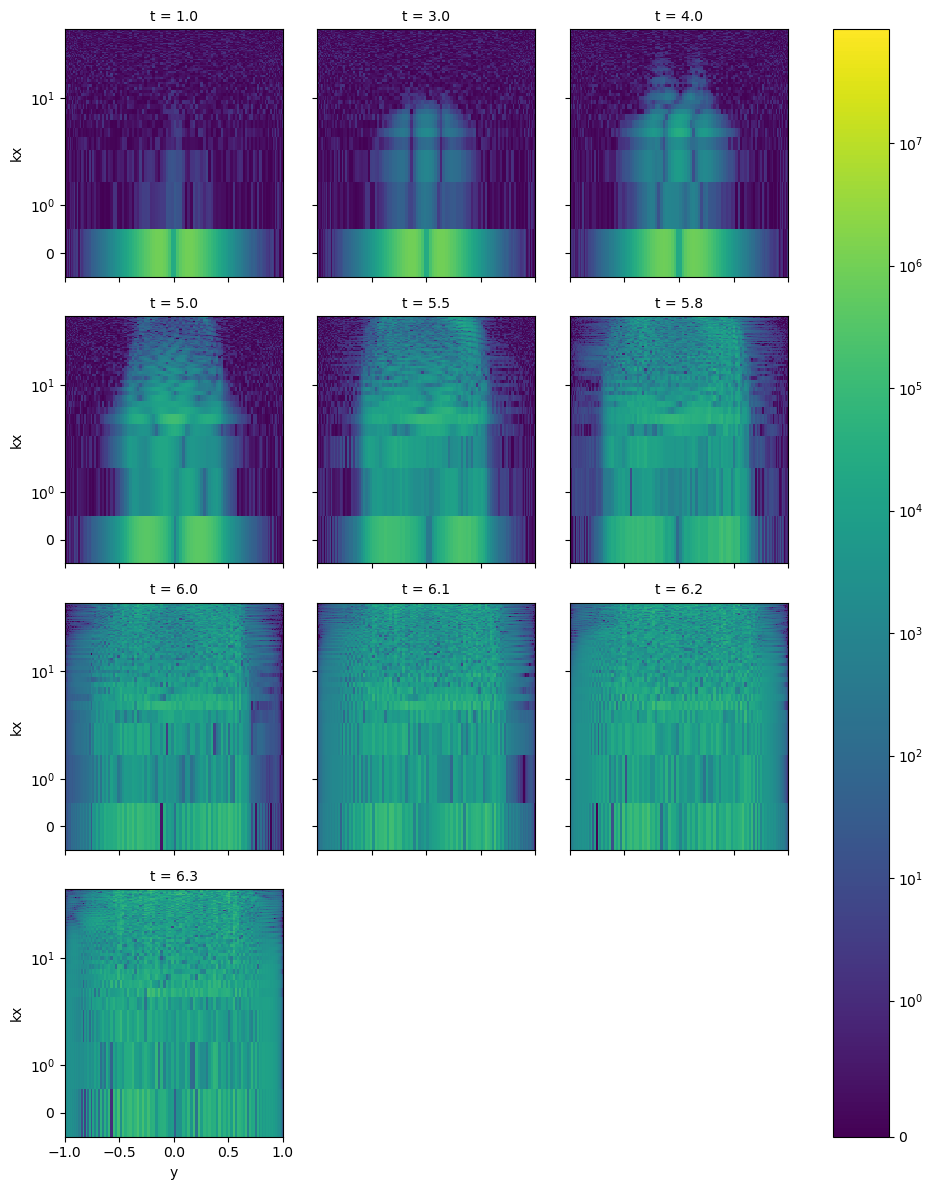

In [108]:
spec_vort_x_w_dealias = PostProcess_w_dealias.var_spectrum_2D(Ds_his_w_dealias['vorticity'], "x")
symlog_norm_w_dealias = mcolors.SymLogNorm(linthresh=1, vmin=0, vmax=spec_vort_x_w_dealias.max(), base=10)
spec_vort_x_w_dealias.sel(t = liste_t_w_dealias, method = 'nearest').plot.pcolormesh(x = 'y',
                                                                                     y= 'kx', 
                                                                                     yscale = 'symlog',
                                                                                     col = 't',
                                                                                     col_wrap = 3,
                                                                                     norm = symlog_norm_w_dealias)

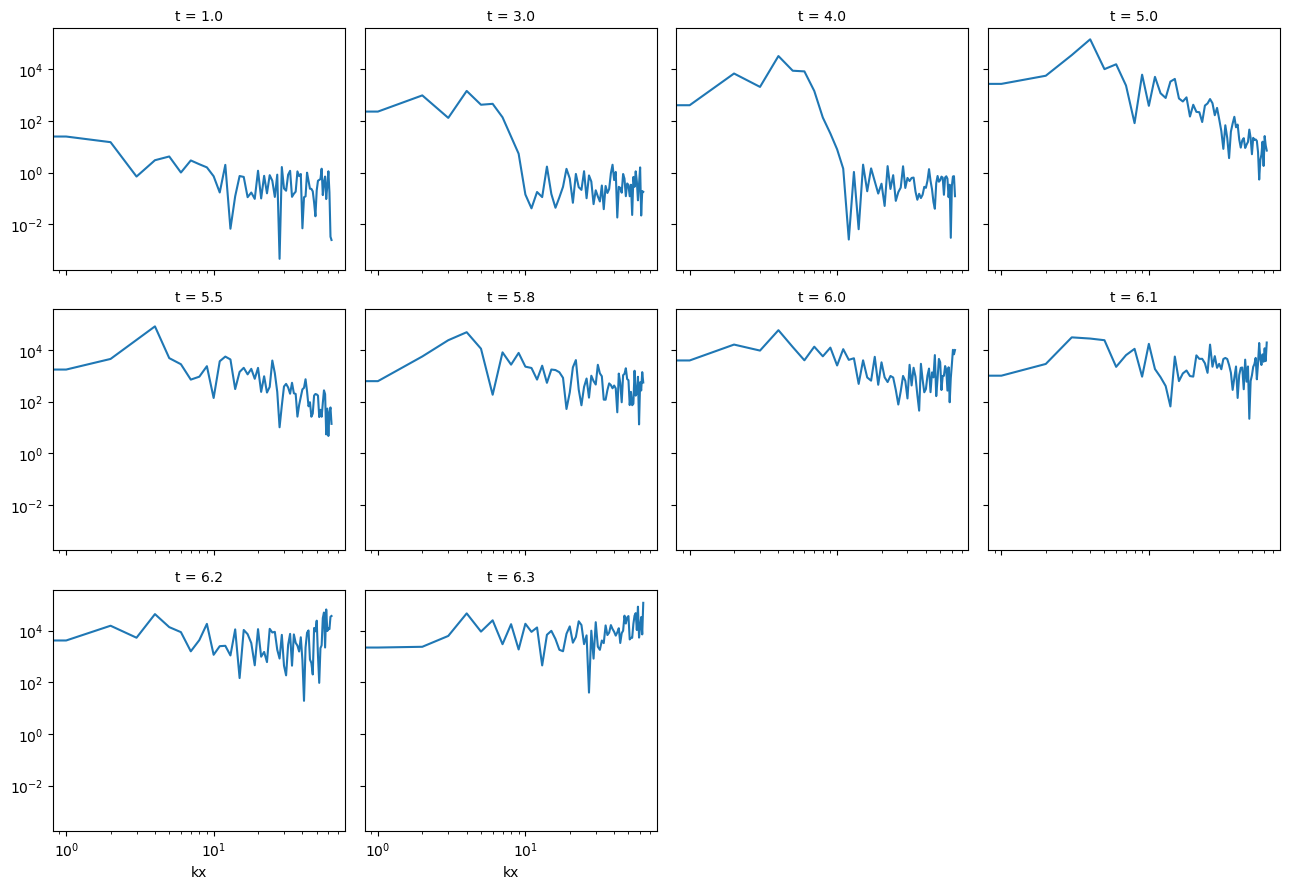

In [21]:
#Vue du spectre au centre du canal
spec_visc_center = spec_vort_x_w_dealias.sel(y = 0.0, method = 'nearest')

spec_visc_center.sel(t = liste_t_w_dealias, method = 'nearest').plot(row = 't', xscale = 'log', yscale = 'log', col_wrap = 4)

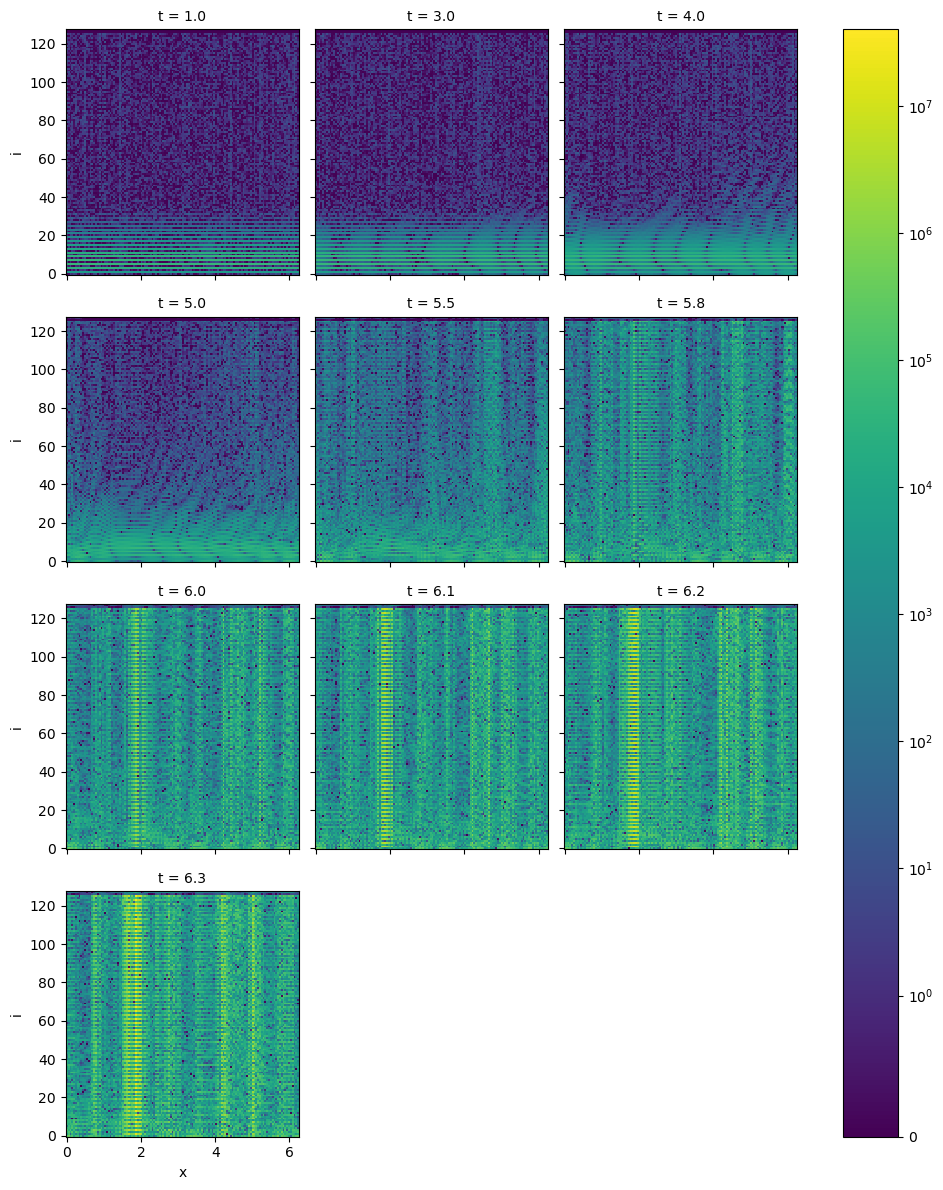

In [107]:
spec_vort_y_w_dealias = PostProcess_w_dealias.var_spectrum_2D(Ds_his_w_dealias['vorticity'], "y")
symlog_norm_w_dealias = mcolors.SymLogNorm(linthresh=1, vmin=0, vmax=spec_vort_y_w_dealias.max(), base=10)
spec_vort_y_w_dealias.sel(t = liste_t_w_dealias, method = 'nearest').plot.pcolormesh(x = 'x',
                                                                                     y= 'i', 
                                                                                     col = 't',
                                                                                     col_wrap = 3,
                                                                                     norm = symlog_norm_w_dealias)

## Comparaison avec la meme simulation faite avec fluid2d

<xarray.Dataset> Size: 948MB
Dimensions:    (y: 512, x: 512, t: 301)
Coordinates:
  * y          (y) float32 2kB 0.001953 0.005859 0.009766 ... 1.99 1.994 1.998
  * x          (x) float32 2kB 0.006136 0.01841 0.03068 ... 6.253 6.265 6.277
  * t          (t) float32 1kB 0.0 0.05 0.1 0.15 0.2 ... 14.85 14.9 14.95 15.0
Data variables:
    msk        (y, x) int32 1MB dask.array<chunksize=(512, 512), meta=np.ndarray>
    kt         (t) int32 1kB dask.array<chunksize=(301,), meta=np.ndarray>
    psi        (t, y, x) float32 316MB dask.array<chunksize=(128, 512, 512), meta=np.ndarray>
    vorticity  (t, y, x) float32 316MB dask.array<chunksize=(128, 512, 512), meta=np.ndarray>
    pv         (t, y, x) float32 316MB dask.array<chunksize=(128, 512, 512), meta=np.ndarray>
Attributes: (12/61)
    modelname:              quasigeostrophic
    expname:                f2d_bickley_w_transport_qg
    timestepping:           RK3_SSP
    order:                  5
    aparab:                 0.05
    flux_splitting_method:  parabolic
    ...                     ...
    plot_var:               vorticity
    beta:                   0.0
    Rd:                     1e+38
    nbproc:                 1
    whosetspsi:             pvanom
    qgoperator:             1

<xarray.Dataset> Size: 6kB
Dimensions:  (t: 301)
Coordinates:
  * t        (t) float32 1kB 0.0 0.05 0.1 0.15 0.2 ... 14.85 14.9 14.95 15.0
Data variables:
    kt       (t) int32 1kB ...
    ke       (t) float32 1kB ...
    pv       (t) float32 1kB ...
    pv2      (t) float32 1kB ...

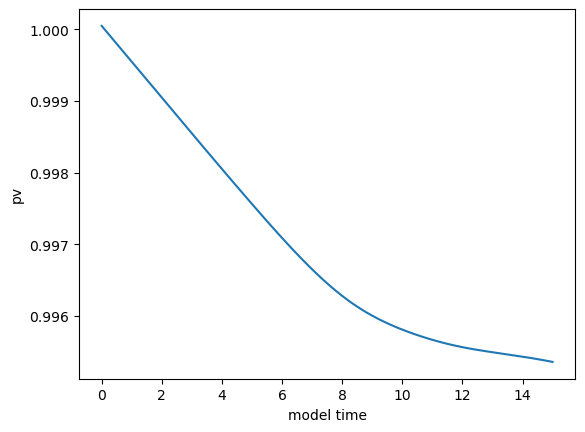

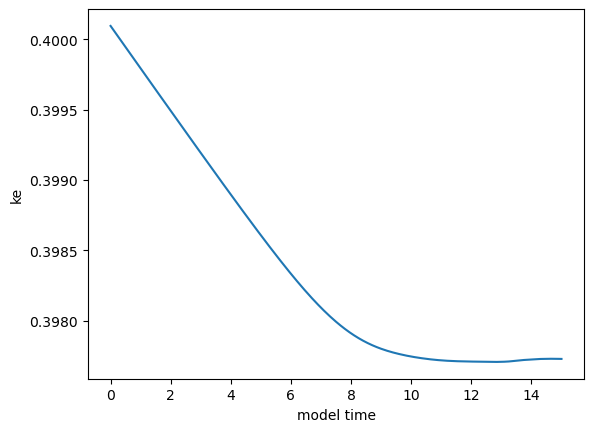

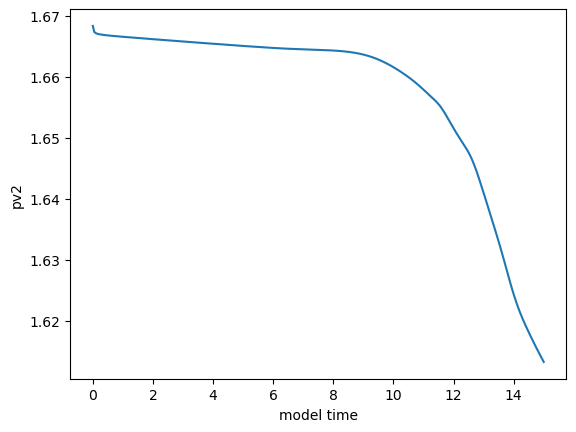

In [23]:
exp_name = 'f2d_bickley_w_transport_qg'

Ds_his_f2d = xr.open_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+'_his.nc', chunks = 'auto')

Ds_diags_f2d = xr.open_dataset(repertoire_courant + rf"//{exp_name}//" + exp_name+"_diag.nc")

ipd.display(Ds_his_f2d)
ipd.display(Ds_diags_f2d)


fig = plt.figure()
Ds_diags_f2d['pv'].plot()



fig = plt.figure()
Ds_diags_f2d['ke'].plot()


fig = plt.figure()
Ds_diags_f2d['pv2'].plot()


In [24]:
ps.animate(Ds_his_f2d['pv'], regular_grid = True)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

In [25]:
ps.animate(Ds_his_f2d['psi'], regular_grid = True)

Column
    [0] HoloViews(DynamicMap, height=500, sizing_mode='fixed', widget_location='bottom', widget_type='scrubber', width=500)
    [1] WidgetBox(align=('center', 'end'))
        [0] Player(end=300, interval=200, show_loop_controls=False, visible_buttons=['previous', 'play', ...], width=550)

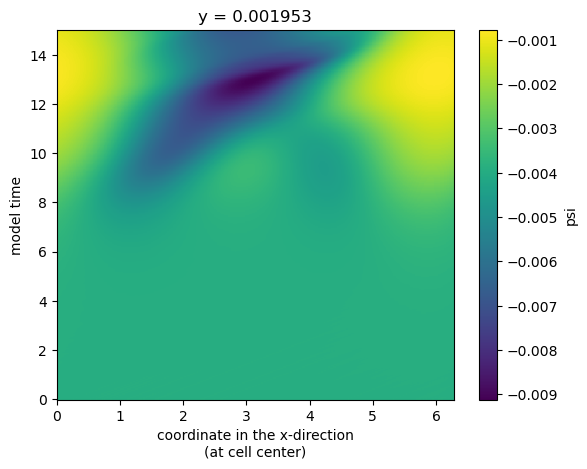

In [26]:
Ds_his_f2d['psi'].isel(y = 0).plot()

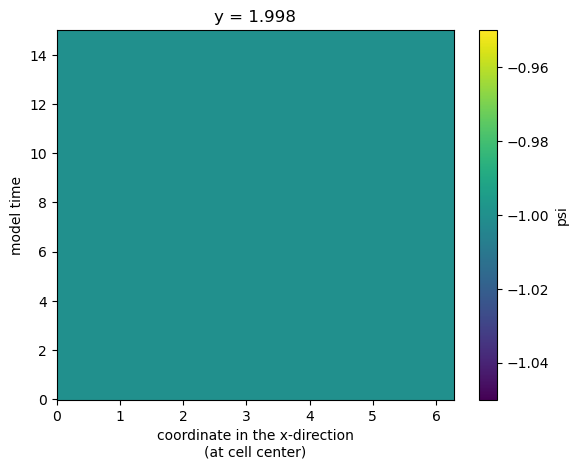

In [27]:
(Ds_his_f2d['psi'] - 1.0).isel(y = -1).plot()

In [28]:
(Ds_his_f2d['psi'] - 1.0).isel(y = -1).values

array([[-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]], dtype=float32)

In [29]:
(Ds_his_f2d['psi'] - 1.0).isel(y = 0).values

array([[-1.0039073, -1.0039072, -1.0039064, ..., -1.0039074, -1.0039072,
        -1.0039071],
       [-1.0039074, -1.0039073, -1.0039072, ..., -1.0039079, -1.0039076,
        -1.0039074],
       [-1.0039084, -1.003908 , -1.0039077, ..., -1.0039076, -1.0039082,
        -1.0039085],
       ...,
       [-1.0010719, -1.0010749, -1.0010782, ..., -1.0010637, -1.0010666,
        -1.0010693],
       [-1.0010825, -1.0010858, -1.0010891, ..., -1.001074 , -1.0010767,
        -1.0010796],
       [-1.0010926, -1.001096 , -1.0010996, ..., -1.0010844, -1.0010868,
        -1.0010896]], dtype=float32)